In [45]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [46]:
import jax
# JAX_DEBUG_NANS=True
# jax.config.update("jax_debug_nans", True)

import jax.numpy as jnp
from flax import linen as nn
import optax
import copy

from typing import Callable

from functools import partial

import tensorflow as tf
import tensorrt

from pyDOE import lhs
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import odeint

import numpy as np

from scipy.optimize import fsolve

import warnings

In [47]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [48]:
print(jax.default_backend())

gpu


In [49]:
def Lorenz1960(vals, t):

  A_val, F_val, G_val = vals

  A_t = -(1/(k**2) - 1/(k**2 + l**2))*(k * l * F_val * G_val)
  F_t = (1/(l**2) - 1/(k**2 + l**2))*(k * l * A_val * G_val)
  G_t = -(1/2)*(1/(l**2) - 1/(k**2))*(k * l * A_val * F_val)

  vals_t = [A_t, F_t, G_t]

  return vals_t

In [50]:
t0, tfinal = 0.0, 5.0

In [51]:
k = 1.0
l = 2.0

In [52]:
@jax.jit
def newton(A, G, A_0, F_0, G_0, E) :

  # print("------------------------------------------------------------------------------------------")

  # print("A", A)
  # print("G", G)

  F = ((4*E - (A**2/l**2) - ((2*(G**2))/(k**2 + l**2)))*(k**2))
  # print("F HERE", F)
  

  # print("F square", F)

  # print("------------------------------------------------------------------------------------------")

  F = jnp.abs(F)
  F = jnp.sqrt(F)

  dF_dA = -(A*(k**2))/(F*(l**2))
  dF_dG = -(2*G*(k**2))/(F*(k**2 + l**2))

  D = (A - A_0)**2 + (F - F_0)**2 + (G - G_0)**2

  H1 = 2*(A - A_0) + 2*(F - F_0)*dF_dA
  H2 = 2*(F - F_0)*dF_dG + 2*(G - G_0)

  H = jnp.array([H1, H2])

  dH1_dA = 2 - (2*(k**2))/(l**2) + ((2*(k**2)*F_0)/(l**2))*((F - (A*dF_dA))/(F**2))
  dH1_dG = -((2*(k**2)*F_0*A)/((F**2)*(l**2)))*dF_dG

  dH2_dA = -((4*(k**2)*F_0*G)/((F**2)*(k**2 + l**2)))*dF_dA
  dH2_dG = -((4*(k**2))/(k**2 + l**2)) + ((4*(k**2)*F_0)/(k**2 + l**2))*((F - (G*dF_dG))/(F**2)) + 2

  J = jnp.array([[dH1_dA, dH1_dG], [dH2_dA, dH2_dG]])

  J = jnp.squeeze(J)

  # print("-----------------------------------------------------------")
    
  # print("A", A)
  # print("F", F)
  # print("G", G)

  # print("dF_dA", dF_dA)
  # print("dF_dG", dF_dG)

  # print("A0", A_0)
  # print("F0", F_0)
  # print("G0", G_0)

  # print("H1", H1)
  # print("H2", H2)

  # print("dH1_dA", dH1_dA)
  # print("dH1_dG", dH1_dG)
  # print("dH2_dA", dH2_dA)
  # print("dH2_dG", dH2_dG)


  # print("-----------------------------------------------------------")
    
  # J_mask = jnp.isfinite(J)
  # J_mask = ~J_mask    
  # J = jnp.where(J_mask, 0., J)
  
  J_inv = jnp.linalg.inv(J)

  # J_inv_mask = jnp.isfinite(J_inv)
  # J_inv_mask = ~J_inv_mask    
  # J_inv = jnp.where(J_inv_mask, 0., J_inv)

  # H_mask = jnp.isfinite(H)
  # H_mask = ~H_mask    
  # H = jnp.where(H_mask, 0., H)
  

  # print("-------------------------------------")

  # sum = jnp.sum(J)
  # print("sum", sum)
  # print("START J", J)
  # print("END J")
  # # print("H", H)

      
  # # print("J_inv", J_inv)

  # print("-------------------------------------")

  return J_inv, H


In [53]:
@jax.jit
def distance_eq(vals) :

  A_0, F_0, G_0, E_0 = vals

  iter = 0
  err = 1000
  delta = 1.0
  gamma = 0.0001

  A = A_0*delta
  F = F_0*delta
  G = G_0*delta


  # print("------------------------------------------------------------------------------------------")

  # print("A", A)

  # print("G", G)


  # print("------------------------------------------------------------------------------------------")

  x_curr = jnp.array([A, G])

  while (iter < 5) :

    # print("--------------------------------------------------------")
    # print("A", A.shape)
    # print("G", G.shape)
    # print("A_0", A_0.shape)
    # print("F_0", F_0.shape)
    # print("G_0", G_0.shape)
    # print("E_0", E_0.shape)
    # print("--------------------------------------------------------")
      
    J_inv, H = newton(A, G, A_0, F_0, G_0, E_0)

    # print("J INVERSE", J_inv)
    # print("H", H)

    # mask_J_inv = jnp.isnan(J_inv)
    # J_inv = jnp.where(mask_J_inv, 0, J_inv)

    # mask_H = jnp.isnan(H)
    # H = jnp.where(mask_H, 0, H)

    # print("x_curr sh", x_curr.shape)
    # print("J_inv sh", J_inv.shape)
    # print("H sh", H.shape)

    x_next = x_curr - jnp.matmul(J_inv, H)

    iter = iter + 1

    x_curr = x_next

    A = x_curr[0]
    G = x_curr[1]

  F = ((4*E_0 - (A**2/l**2) - gamma*((2*(G**2))/(k**2 + l**2)))*(k**2))
  F = jnp.abs(F)
  F = jnp.sqrt(F)

  return A, F, G

@jax.jit
def find_closest(vals) :

  return jax.vmap(distance_eq, 0)(vals)

In [54]:
class Normalize(nn.Module):
  xmin: float
  xmax: float

  @nn.compact
  def __call__(self, x):
    return 2.0*(x-self.xmin)/(self.xmax - self.xmin) - 1.0

In [55]:
class HardConstraint(nn.Module):
  t0: float
  tfinal: float
  u0: float

  @nn.compact
  def __call__(self, inputs):
    t, nn = inputs
    return self.u0 + (t-self.t0)/(self.tfinal-self.t0)*nn

In [56]:
class ClosestPoint(nn.Module):

  E_0: float

  @nn.compact
  def __call__(self, inputs):

    A, F, G = inputs

    A_final, F_final, G_final = find_closest([A, F, G, self.E_0])

    return A_final, F_final, G_final

In [57]:
class CombineBranches(nn.Module):
  @nn.compact
  def __call__(self, inp1, inp2):
    mult = jnp.sum(inp1*inp2, axis=1)
    out = jnp.reshape(mult, (-1,1))
    return out

In [58]:
class MLP(nn.Module):

  layers: int
  units: int

  @nn.compact
  def __call__(self, inp):
    b = inp
    for i in range(self.layers-1):
      b = nn.Dense(self.units)(b)
      b = nn.tanh(b)
    out = nn.Dense(4*self.units)(b)
    return out

In [59]:
def define_collocation_points(t_bdry, N=100):

  ode_points = t_bdry[0] + (t_bdry[1] - t_bdry[0])*lhs(1, N)

  As = np.random.uniform(0.0, 1.0, size = (N, 1))
  Fs = np.random.uniform(0.0, 1.0, size = (N, 1))
  Gs = np.random.uniform(0.0, 1.0, size = (N, 1))
  Es = (1/4)*((As**2/l**2) + (Fs**2/k**2) + (2*(Gs**2)/(k**2 + l**2)))
  Vs = (1/2)*(As**2 + Fs**2 + 2*(Gs**2))

  # F_test = ((4*Es - (As**2/l**2) - ((2*(Gs**2))/(k**2 + l**2)))*(k**2))
  # for num in F_test :
  #     print(num)

  sensor_points = np.column_stack((As, Fs, Gs, Es, Vs))

  return (ode_points, sensor_points)

In [60]:
(de_points, sensors) = define_collocation_points([t0, tfinal], 500)
print(de_points.shape, sensors.shape)

(500, 1) (500, 5)


In [61]:
class DeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, t, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    A_0 = u[:,:1]
    F_0 = u[:,1:2]
    G_0 = u[:,2:3]
    E_0 = u[:,3:4]
    V_0 = u[:,4:]

    u = u[:,:3]

    t = jnp.reshape(t, (-1,1))

    b = Normalize(self.t0, self.tfinal)(t)

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    A_tr = trunk_net[:,:self.units]
    F_tr = trunk_net[:,self.units:2*self.units]
    G_tr = trunk_net[:,2*self.units:]
    # E_tr = trunk_net[:,3*self.units:4*self.units]
    # V_tr = trunk_net[:,4*self.units:]

    A_br = branch_net[:,:self.units]
    F_br = branch_net[:,self.units:2*self.units]
    G_br = branch_net[:,2*self.units:]
    # E_br = branch_net[:,3*self.units:4*self.units]
    # V_br = branch_net[:,4*self.units:]

    A = CombineBranches()(A_tr, A_br)
    F = CombineBranches()(F_tr, F_br)
    G = CombineBranches()(G_tr, G_br)

    A = HardConstraint(self.t0, self.tfinal, A_0)([t, A])
    F = HardConstraint(self.t0, self.tfinal, F_0)([t, F])
    G = HardConstraint(self.t0, self.tfinal, G_0)([t, G])

    A = jnp.reshape(A, (-1,))
    F = jnp.reshape(F, (-1,))
    G = jnp.reshape(G, (-1,))

    return A, F, G

In [62]:
@partial(jax.jit, static_argnums=(2,))
def var_model(t, z, component, params):
  return deeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def var(t, z, component, params):
  return jax.vmap(var_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def var_t(t, z, component, params):
  return jax.vmap(jax.grad(var_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def loss(params, t, z):

  A_t_loss_w = 1.0
  F_t_loss_w = 1.0
  G_t_loss_w = 1.0

  diff_loss_w = 1.0
  E_loss_w = 1.0
  V_loss_w = 1.0

  E_0_val = z[:, -2]
  V_0_val = z[:, -1]

  A_val = var(t, z, 0, params)
  F_val = var(t, z, 1, params)
  G_val = var(t, z, 2, params)

  E_val = (0.25)*((A_val**2/l**2) + (F_val**2/k**2) + (2.*(G_val**2)/(k**2 + l**2)))
  E_loss = E_val - E_0_val
  E_loss = jnp.square(E_loss)
  E_loss = jnp.mean(E_loss)


  V_val = (0.5)*(A_val**2 + F_val**2 + 2.*(G_val**2))
  V_loss = V_val - V_0_val
  V_loss = jnp.square(V_loss)
  V_loss = jnp.mean(V_loss)


  A_t_val = var_t(t, z, 0, params)
  F_t_val = var_t(t, z, 1, params)
  G_t_val = var_t(t, z, 2, params)

  A_t_loss = A_t_val + (1./(k**2) - 1./(k**2 + l**2))*(k * l * F_val * G_val)
  A_t_loss = jnp.square(A_t_loss)
  A_t_loss = jnp.mean(A_t_loss)


  F_t_loss = F_t_val - (1./(l**2) - 1./(k**2 + l**2))*(k * l * A_val * G_val)
  F_t_loss = jnp.square(F_t_loss)
  F_t_loss = jnp.mean(F_t_loss)

  G_t_loss = G_t_val + (0.5)*(1./(l**2) - 1./(k**2))*(k * l * A_val * F_val)
  G_t_loss = jnp.square(G_t_loss)
  G_t_loss = jnp.mean(G_t_loss)

  diff_loss = A_t_loss_w*A_t_loss + F_t_loss_w*F_t_loss + G_t_loss_w*G_t_loss

  final_loss = diff_loss_w*diff_loss + E_loss_w*E_loss + V_loss_w*V_loss

  return final_loss

@jax.jit
def train_step(params, pdes, z):
  t = pdes[:,0]
  return jax.value_and_grad(loss)(params, t, z)

@partial(jax.jit, static_argnums=(3,))
def optimize(grads, opt_state, params, optimizer_update):
  updates, opt_state = optimizer_update(grads, opt_state, params)
  params = optax.apply_updates(params, updates)
  return params, opt_state

In [63]:
def train_network(params, des, sensors, epochs=100):

  N = de_points.shape[0]

  nr_batches = 10
  batch_size = len(des)//nr_batches

  print("batch size:", batch_size)

  lr = 1e-3
  optimizer = optax.adam(lr)
  opt_state = optimizer.init(params)

  ds_z = tf.data.Dataset.from_tensor_slices(sensors)
  ds_de = tf.data.Dataset.from_tensor_slices(des)

  ds = tf.data.Dataset.zip((ds_de, ds_z))
  ds = ds.shuffle(N).batch(batch_size)

  epoch_loss = np.zeros(epochs)

  for i in range(epochs):

    for (des_batch, z_batch) in ds:

      loss, grads = train_step(params, des_batch.numpy(), z_batch.numpy())
      params, opt_state = optimize(grads, opt_state, params, optimizer.update)

      epoch_loss[i] += loss

    epoch_loss[i] /= batch_size

    if i % 100  == 0:
      print(f'Loss in epoch {i}: {epoch_loss[i]}')

  return params, epoch_loss

In [64]:
deeponet = DeepONet(t0, tfinal, layers=4, units=40)

t_init = jnp.full((10, ), 1.0)
u_init = jnp.full((10, 5), 1.0)

params = deeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [65]:
param_count = sum(x.size for x in jax.tree.leaves(params))
print(param_count)

19920


In [66]:
epochs = 2000
params, loss = train_network(params, de_points, sensors, epochs)

batch size: 50
Loss in epoch 0: 0.08956200599670411
Loss in epoch 100: 0.0020528759062290194
Loss in epoch 200: 0.0012802173197269439
Loss in epoch 300: 0.0013765731453895568
Loss in epoch 400: 0.0007670392096042633
Loss in epoch 500: 0.0015232379734516144
Loss in epoch 600: 0.0018700253963470459
Loss in epoch 700: 0.0018009540438652038
Loss in epoch 800: 0.0005001472681760788
Loss in epoch 900: 0.00048490695655345917
Loss in epoch 1000: 0.0006622420251369476
Loss in epoch 1100: 0.0005289909616112709
Loss in epoch 1200: 0.0002904530242085457
Loss in epoch 1300: 0.0003473052754998207
Loss in epoch 1400: 0.0004851669818162918
Loss in epoch 1500: 0.0004881924390792847
Loss in epoch 1600: 0.00028974171727895736
Loss in epoch 1700: 0.0002637133188545704
Loss in epoch 1800: 0.00015596255660057067
Loss in epoch 1900: 0.00037539880722761156


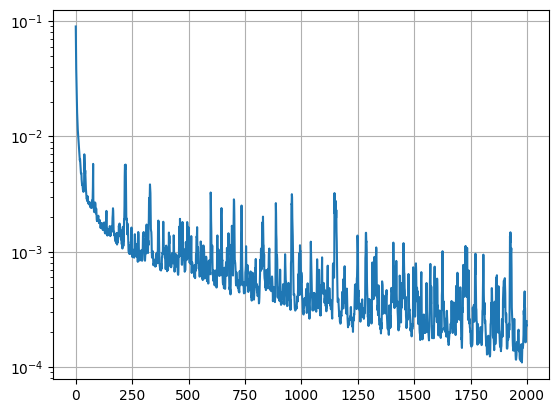

In [67]:
plt.semilogy(loss)
plt.grid()

In [68]:
n = 500
t = np.linspace(t0, tfinal, n)

A_data = np.random.uniform(0.0, 1.0, size=(1,))
F_data = np.random.uniform(0.0, 1.0, size=(1,))
G_data = np.random.uniform(0.0, 1.0, size=(1,))
E_data = (1/4)*((A_data**2/l**2) + (F_data**2/k**2) + (2*(G_data**2)/(k**2 + l**2)))
V_data = (1/2)*(A_data**2 + F_data**2 + 2*(G_data**2))

init_data_rk = np.column_stack((A_data, F_data, G_data))
init_data_rk = np.squeeze(init_data_rk)

init_data_model = np.column_stack((A_data, F_data, G_data, E_data, V_data))
init_data_model = np.squeeze(init_data_model)
print(init_data_model.shape)

z = np.repeat(np.expand_dims(init_data_model, axis=0), len(t), axis=0)
print(z.shape)

(5,)
(500, 5)


In [69]:
sol_rk = odeint(Lorenz1960, init_data_rk, t)
A_rk, F_rk, G_rk = sol_rk[:,0], sol_rk[:,1], sol_rk[:,2]
E_rk = (1/4)*((A_rk**2/l**2) + (F_rk**2/k**2) + (2*(G_rk**2)/(k**2 + l**2)))

In [70]:
A = jax.vmap(var_model, [0, 0, None, None])(t, z, 0, params)
F = jax.vmap(var_model, [0, 0, None, None])(t, z, 1, params)
G = jax.vmap(var_model, [0, 0, None, None])(t, z, 2, params)

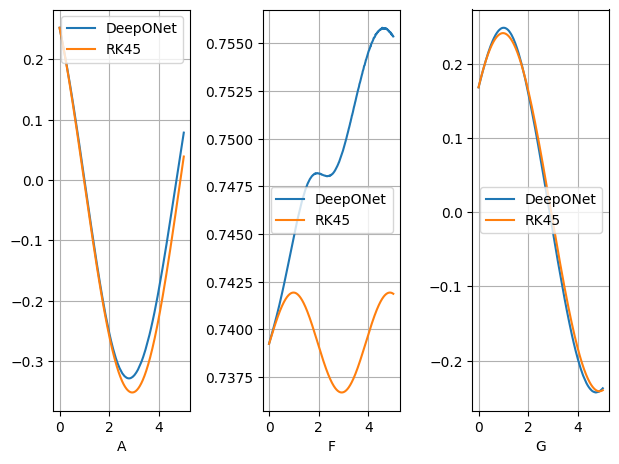

In [71]:
fig = plt.figure()

plt.subplot(1, 3, 1)
plt.tight_layout()
plt.plot(t, A)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(1, 3, 2)
plt.tight_layout()
plt.plot(t, F)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(1, 3, 3)
plt.tight_layout()
plt.plot(t, G)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.show()

In [72]:
class CDeepONet(nn.Module):

  t0: float
  tfinal: float
  layers: int
  units: int

  @nn.compact
  def __call__(self, t, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    A_0 = u[:,:1]
    F_0 = u[:,1:2]
    G_0 = u[:,2:3]
    E_0 = u[:,3:4]
    V_0 = u[:,4:]


    u = u[:,:3]

    t = jnp.reshape(t, (-1,1))

    b = Normalize(self.t0, self.tfinal)(t)

    # print("U", u)
    # print("B", b)

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    A_tr = trunk_net[:,:self.units]
    F_tr = trunk_net[:,self.units:2*self.units]
    G_tr = trunk_net[:,2*self.units:]
    # E_tr = trunk_net[:,3*self.units:4*self.units]
    # V_tr = trunk_net[:,4*self.units:]

    A_br = branch_net[:,:self.units]
    F_br = branch_net[:,self.units:2*self.units]
    G_br = branch_net[:,2*self.units:]
    # E_br = branch_net[:,3*self.units:4*self.units]
    # V_br = branch_net[:,4*self.units:]

    A = CombineBranches()(A_tr, A_br)
    F = CombineBranches()(F_tr, F_br)
    G = CombineBranches()(G_tr, G_br)

    # print("AFTER COMB A", A, F, G)

    A = HardConstraint(self.t0, self.tfinal, A_0)([t, A])
    F = HardConstraint(self.t0, self.tfinal, F_0)([t, F])
    G = HardConstraint(self.t0, self.tfinal, G_0)([t, G])

    # print("----------------------------------------------------------------------------------------")
    # print("BEFORE")
    # print("A", A)
    # print("F", F)
    # print("G", G)

    A, F, G = ClosestPoint(E_0)([A, F, G])

    # print("AFTER")
    # print("A", A)
    # print("F", F)
    # print("G", G)

    # print("----------------------------------------------------------------------------------------")

    A = jnp.reshape(A, (-1,))
    F = jnp.reshape(F, (-1,))
    G = jnp.reshape(G, (-1,))

    return A, F, G

In [73]:
@partial(jax.jit, static_argnums=(2,))
def Cvar_model(t, z, component, params):
  return Cdeeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def Cvar(t, z, component, params):
  return jax.vmap(Cvar_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def Cvar_t(t, z, component, params):
  return jax.vmap(jax.grad(Cvar_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def Closs(params, t, z):

  A_t_loss_w = 1.0
  F_t_loss_w = 1.0
  G_t_loss_w = 1.0

  diff_loss_w = 1.0
  E_loss_w = 0.0
  V_loss_w = 0.0

  E_0_val = z[:, -2]
  V_0_val = z[:, -1]

  # print("PARAMS", params)

  A_val = Cvar(t, z, 0, params)
  F_val = Cvar(t, z, 1, params)
  G_val = Cvar(t, z, 2, params)

  E_val = (0.25)*((A_val**2/l**2) + (F_val**2/k**2) + (2.*(G_val**2)/(k**2 + l**2)))
  E_loss = E_val - E_0_val
  E_loss = jnp.square(E_loss)
  E_loss = jnp.mean(E_loss)


  V_val = (0.5)*(A_val**2 + F_val**2 + 2*(G_val**2))
  V_loss = V_val - V_0_val
  V_loss = jnp.square(V_loss)
  V_loss = jnp.mean(V_loss)


  A_t_val = Cvar_t(t, z, 0, params)  
  F_t_val = Cvar_t(t, z, 1, params)
  G_t_val = Cvar_t(t, z, 2, params)

  # mask = jnp.isfinite(A_t_val)
  # mask = ~mask

  # print("AFG VALS BEFORE")

  # print("A_val", A_val)
  # print("F_val", F_val)
  # print("G_val", G_val)

  # print("AFG_T VALS BEFORE")

  # print("A_t_val", A_t_val)
  # print("F_t_val", F_t_val)
  # print("G_t_val", G_t_val)

  # A_val = jnp.where(mask, 0., A_val)
  # F_val = jnp.where(mask, 0., F_val)
  # G_val = jnp.where(mask, 0., G_val)

  # A_t_val = jnp.where(mask, 0., A_t_val)
  # F_t_val = jnp.where(mask, 0., F_t_val)
  # G_t_val = jnp.where(mask, 0., G_t_val)


  # print("AFG VALS AFTER")

  # print("A_val", A_val)
  # print("F_val", F_val)
  # print("G_val", G_val)

  # print("AFG_T VALS AFTER")

  # print("A_t_val", A_t_val)
  # print("F_t_val", F_t_val)
  # print("G_t_val", G_t_val)

  A_t_loss = A_t_val + (1./(k**2) - 1./(k**2 + l**2))*(k * l * F_val * G_val)
  A_t_loss = jnp.square(A_t_loss)
  A_t_loss = jnp.mean(A_t_loss)

  F_t_loss = F_t_val - (1./(l**2) - 1./(k**2 + l**2))*(k * l * A_val * G_val)
  F_t_loss = jnp.square(F_t_loss)
  F_t_loss = jnp.mean(F_t_loss)

  G_t_loss = G_t_val + (0.25)*(1./(l**2) - 1./(k**2))*(k * l * A_val * F_val)
  G_t_loss = jnp.square(G_t_loss)
  G_t_loss = jnp.mean(G_t_loss)

  diff_loss = A_t_loss_w*A_t_loss + F_t_loss_w*F_t_loss + G_t_loss_w*G_t_loss

  final_loss = diff_loss_w*diff_loss + E_loss_w*E_loss + V_loss_w*V_loss

  # print("----------------------------------------------------------------------------------------")
    
  # print("AT LOSS", A_t_loss)
  # print("FT LOSS", F_t_loss)
  # print("GT LOSS", G_t_loss)
  # print("diff_loss, E_loss, V_loss", diff_loss, E_loss, V_loss)
    
  # print("----------------------------------------------------------------------------------------")

  return final_loss

@jax.jit
def Ctrain_step(params, pdes, z):
  t = pdes[:,0]
    
  return jax.value_and_grad(Closs)(params, t, z)

@partial(jax.jit, static_argnums=(3,))
def Coptimize(grads, opt_state, params, optimizer_update):
  updates, opt_state = optimizer_update(grads, opt_state, params)
  params = optax.apply_updates(params, updates)
  return params, opt_state

In [74]:
def Ctrain_network(params, des, sensors, epochs=100):

  N = de_points.shape[0]

  nr_batches = 10
  batch_size = len(des)//nr_batches

  print("batch size:", batch_size)

  lr = 1e-3
  optimizer = optax.adam(lr)
  opt_state = optimizer.init(params)

  ds_z = tf.data.Dataset.from_tensor_slices(sensors)
  ds_de = tf.data.Dataset.from_tensor_slices(des)

  ds = tf.data.Dataset.zip((ds_de, ds_z))
  ds = ds.shuffle(N).batch(batch_size)

  epoch_loss = np.zeros(epochs)

  batch_no = 0

  for i in range(epochs):

    print(i)

    for (des_batch, z_batch) in ds:

      print("BATCH NUMBER", batch_no)

      # if batch_no == 9 :
          
      #     input()

      # print("PARAMS--------------------------------------------------")
      # print(params)
        
      batch_no = batch_no + 1

      loss, grads = Ctrain_step(params, des_batch.numpy(), z_batch.numpy())
      params, opt_state = Coptimize(grads, opt_state, params, optimizer.update)
        
      epoch_loss[i] += loss

    epoch_loss[i] /= batch_size

    if i % 1  == 0:
      print(f'Loss in epoch {i}: {epoch_loss[i]}')

  return params, epoch_loss

In [75]:
Cdeeponet = CDeepONet(t0, tfinal, layers=4, units=40)

t_init = jnp.full((10, ), 1.0)
u_init = jnp.full((10, 5), 1.0)

Cparams = Cdeeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [76]:
Cparam_count = sum(x.size for x in jax.tree.leaves(Cparams))
print(Cparam_count)

19920


In [77]:
Cparams = copy.deepcopy(params)

In [78]:
#

In [79]:
epochs = 100
Cparams, Closs = Ctrain_network(Cparams, de_points, sensors, epochs)

batch size: 50
0
BATCH NUMBER 0
BATCH NUMBER 1
BATCH NUMBER 2
BATCH NUMBER 3
BATCH NUMBER 4
BATCH NUMBER 5
BATCH NUMBER 6
BATCH NUMBER 7
BATCH NUMBER 8
BATCH NUMBER 9
Loss in epoch 0: 0.03607524394989014
1
BATCH NUMBER 10
BATCH NUMBER 11
BATCH NUMBER 12
BATCH NUMBER 13
BATCH NUMBER 14
BATCH NUMBER 15
BATCH NUMBER 16
BATCH NUMBER 17
BATCH NUMBER 18
BATCH NUMBER 19
Loss in epoch 1: 0.03142997980117798
2
BATCH NUMBER 20
BATCH NUMBER 21
BATCH NUMBER 22
BATCH NUMBER 23
BATCH NUMBER 24
BATCH NUMBER 25
BATCH NUMBER 26
BATCH NUMBER 27
BATCH NUMBER 28
BATCH NUMBER 29
Loss in epoch 2: 0.020779659748077394
3
BATCH NUMBER 30
BATCH NUMBER 31
BATCH NUMBER 32
BATCH NUMBER 33
BATCH NUMBER 34
BATCH NUMBER 35
BATCH NUMBER 36
BATCH NUMBER 37
BATCH NUMBER 38
BATCH NUMBER 39
Loss in epoch 3: 0.03374223947525024
4
BATCH NUMBER 40
BATCH NUMBER 41
BATCH NUMBER 42
BATCH NUMBER 43
BATCH NUMBER 44
BATCH NUMBER 45
BATCH NUMBER 46
BATCH NUMBER 47
BATCH NUMBER 48
BATCH NUMBER 49
Loss in epoch 4: 0.03042930603027343

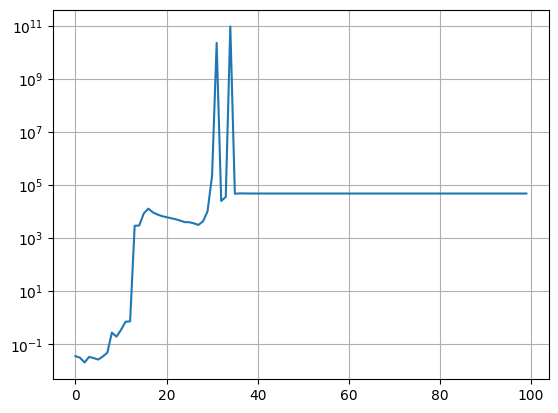

In [80]:
plt.semilogy(Closs)
plt.grid()

In [81]:
A = jax.vmap(Cvar_model, [0, 0, None, None])(t, z, 0, Cparams)
F = jax.vmap(Cvar_model, [0, 0, None, None])(t, z, 1, Cparams)
G = jax.vmap(Cvar_model, [0, 0, None, None])(t, z, 2, Cparams)
E = (1/4)*((A**2/l**2) + (F**2/k**2) + (2*(G**2)/(k**2 + l**2)))

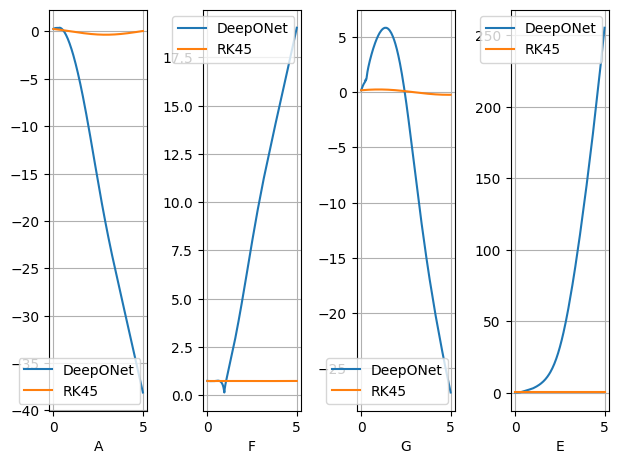

In [82]:
fig = plt.figure()

plt.subplot(1, 4, 1)
plt.tight_layout()
plt.plot(t, A)
plt.plot(t, A_rk)
plt.xlabel("A")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(1, 4, 2)
plt.tight_layout()
plt.plot(t, F)
plt.plot(t, F_rk)
plt.xlabel("F")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(1, 4, 3)
plt.tight_layout()
plt.plot(t, G)
plt.plot(t, G_rk)
plt.xlabel("G")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.subplot(1, 4, 4)
plt.tight_layout()
plt.plot(t, E)
plt.plot(t, E_rk)
plt.xlabel("E")
plt.grid()
plt.legend(['DeepONet','RK45'])

plt.show()
